# Modelado con Regresión Lineal
## Selección de Características y Entrenamiento de Modelos

Este notebook toma los datos preprocesados del EDA y construye modelos de regresión para predecir el precio spot de energía eléctrica en Guatemala (Q/MWh).

**Flujo:**
1. Ingeniería de características adicionales sobre los datos procesados
2. División de datos (entrenamiento / prueba)
3. Entrenamiento con búsqueda de hiperparámetros
4. Evaluación y visualización de resultados

In [1]:
import warnings

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error

### Exploración de Regresión Polinomial

En los siguientes gráficos, exploramos la efectividad de la regresión polinomial sobre los features que elegimos.

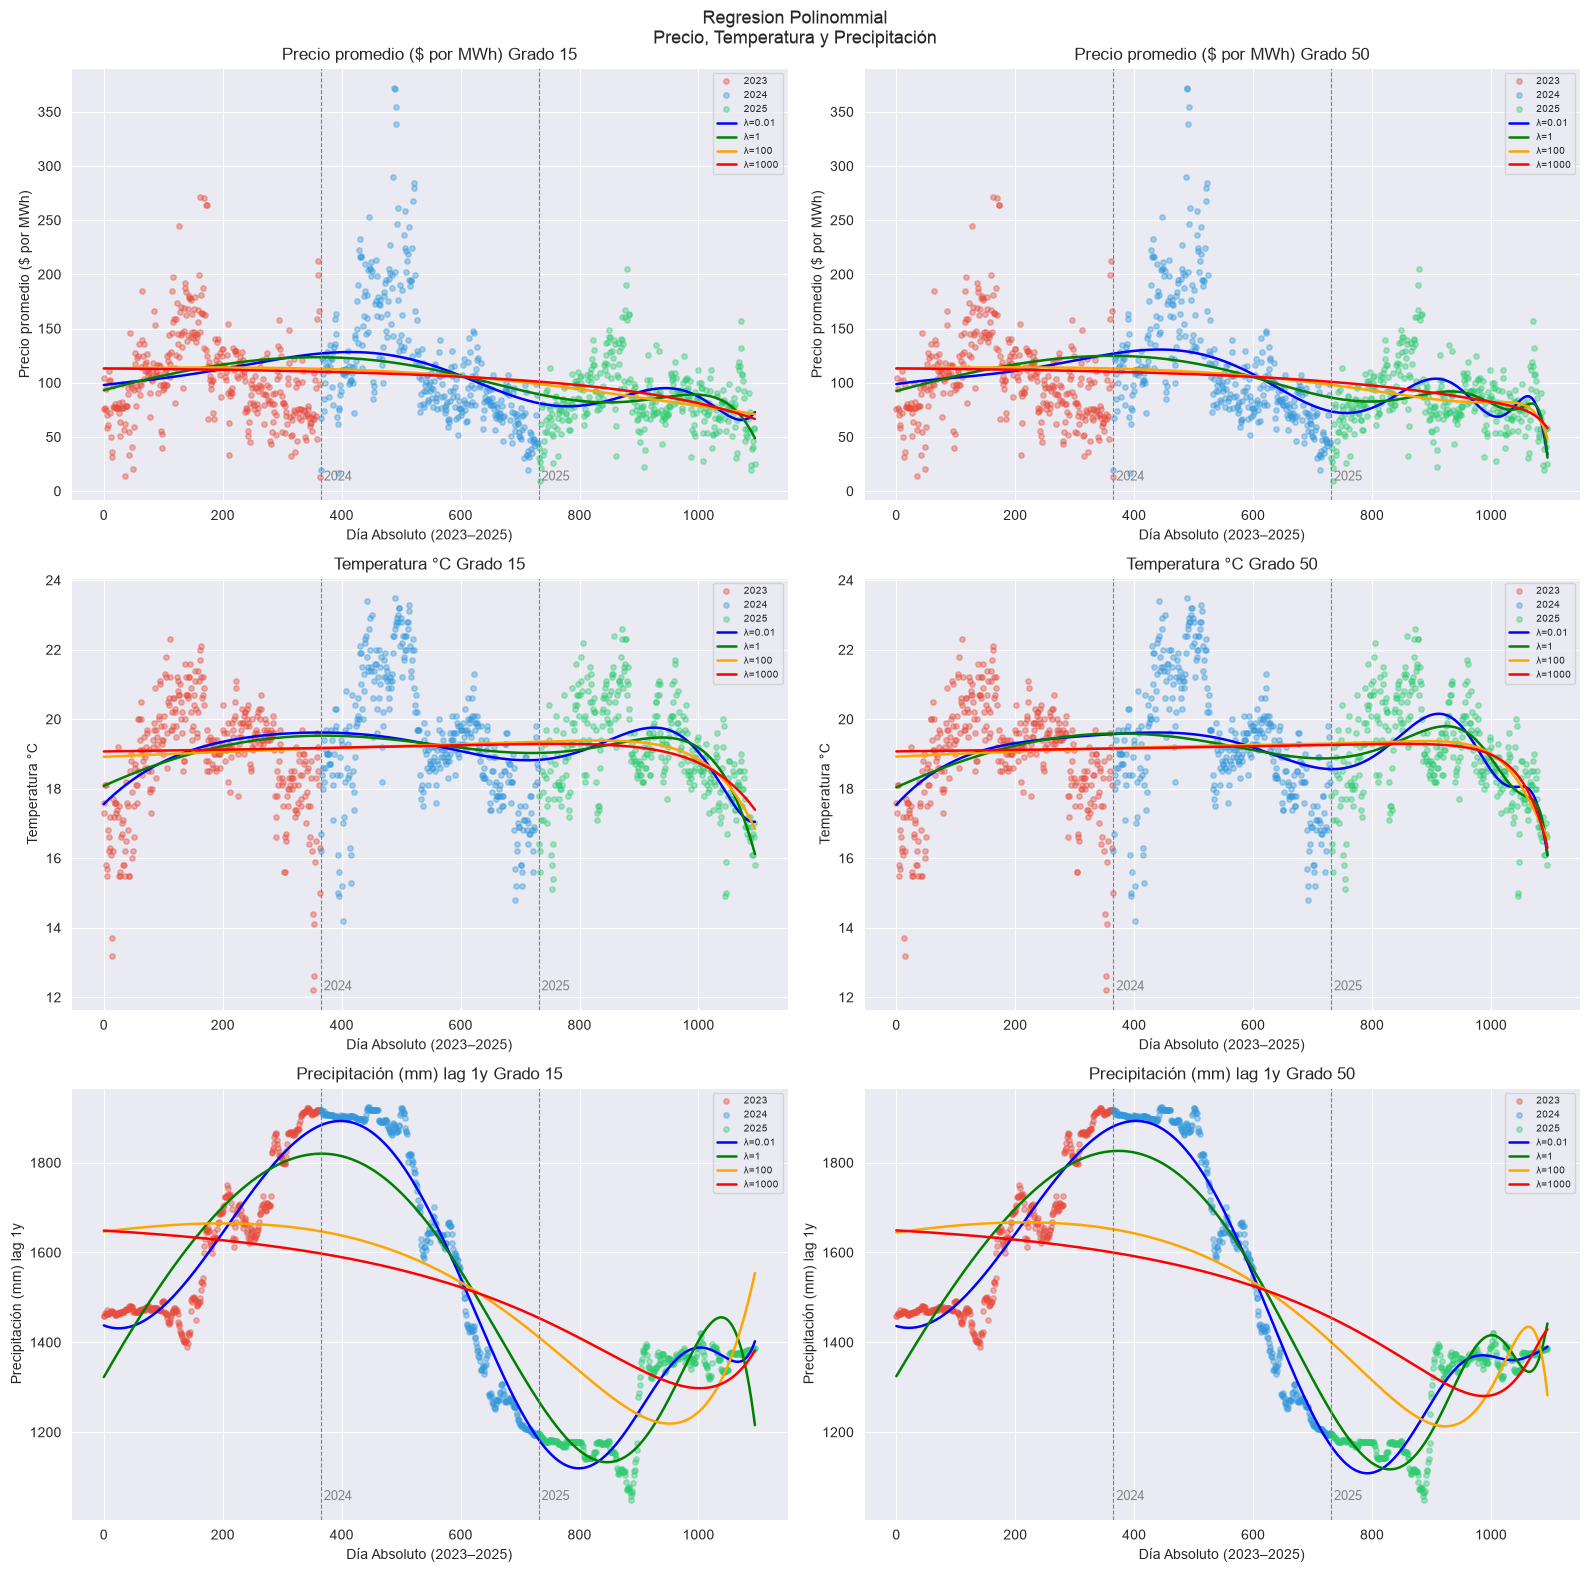

In [18]:
data = pd.read_csv('data/ProcessedData-2023-to-2025.csv', parse_dates=['dia'])
data = data.sort_values(['dia', 'hora']).reset_index(drop=True)
data = data.dropna(subset=['precio'])

daily = data.groupby('dia').agg(
    precio=('precio', 'mean'),
    temperature=('temperature', 'mean'),
    precip_lag_1y=('precip_lag_1y', 'first'),
).reset_index()
daily['year']    = daily['dia'].dt.year
daily['dia_abs'] = (daily['dia'] - daily['dia'].min()).dt.days

X = daily['dia_abs'].values.reshape(-1, 1)
y = daily['precio'].values

X_plot = np.linspace(0, daily['dia_abs'].max(), 1000).reshape(-1, 1)

fig, axes = plt.subplots(3, 2, figsize=(16, 16))

grados      = [15, 50]
lambdas     = [0.01, 1, 100, 1000]
line_colors = ['blue', 'green', 'orange', 'red']
year_colors = {2023: '#e74c3c', 2024: '#3498db', 2025: '#2ecc71'}

external_features = [
    ('precio',        'Precio promedio ($ por MWh)'),
    ('temperature',   'Temperatura °C'),
    ('precip_lag_1y', 'Precipitación (mm) lag 1y'),
]

for row, (feature, ylabel) in enumerate(external_features):
    y_feat = daily[feature].values

    for col, grado in enumerate(grados):
        ax = axes[row, col]

        for year, group in daily.groupby('year'):
            ax.scatter(group['dia_abs'], group[feature],
                       color=year_colors[year], alpha=0.4, s=15, label=str(year))

        for lam, color in zip(lambdas, line_colors):
            model = Pipeline([
                ('poly',   PolynomialFeatures(degree=grado, include_bias=False)),
                ('scaler', StandardScaler()),
                ('ridge',  Ridge(alpha=lam))
            ])
            model.fit(X, y_feat)
            y_hat = model.predict(X_plot)
            ax.plot(X_plot, y_hat, color=color, linewidth=1.8, label=f'λ={lam}')

        for year in [2024, 2025]:
            boundary = daily.loc[daily['year'] == year, 'dia_abs'].min()
            ax.axvline(x=boundary, color='gray', linestyle='--', linewidth=0.8)
            ax.text(boundary + 5, daily[feature].min(), str(year), fontsize=9, color='gray')

        ax.set_title(f'{ylabel} Grado {grado}')
        ax.set_xlabel('Día Absoluto (2023–2025)')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=7)

plt.suptitle('Regresion Polinommial\nPrecio, Temperatura y Precipitación', fontsize=13)
plt.tight_layout()
plt.show()


### Ingeniería y Selección de Características

Partimos de los datos preprocesados en el EDA y agregamos tres capas de features adicionales.

Primero, extendemos el encoding sinusoidal del día del año con harmónicas de orden 2 y 3: el análisis FFT mostró picos de potencia a 365, 180 y 90 días, y una sola sinusoide (k=1) solo puede capturar el ciclo anual principal.

Las harmónicas adicionales permiten al modelo representar el pico de mayo-junio y el valle secundario de noviembre sin necesitar features categóricas por mes.

Segundo, descartamos los lags de precio: en experimentos anteriores observamos que agregarlos elevaba el R² artificialmente porque el modelo simplemente aprendía que el precio de hoy es similar al de ayer, lo cual no es útil para predicción a horizonte de días o semanas.

Tercero, generamos términos polinomiales de grado 3 sobre temperatura, precipitación acumulada, día absoluto y hora.

El análisis de regresión polinomial confirmó que estas variables tienen relaciones no-lineales con el precio — especialmente la temperatura, cuyo efecto se dispara por encima de ciertos umbrales de sequía — y los términos de interacción entre ellas capturan el efecto combinado que ninguna variable explica sola.

Finalmente, excluimos las dummies de hora individuales (23 columnas) porque la variable `hora` como término polinomial ya captura el ciclo diario de forma más compacta y sin la penalización de dimensionalidad.

In [2]:
data = data.sort_values(['dia', 'hora']).reset_index(drop=True)
data = data.dropna(subset=['precio'])

# El análisis FFT reveló periodicidades anuales, semestrales y trimestrales.
# Agregamos harmónicas adicionales de seno/coseno para capturar esas frecuencias
# que el encoding original (solo k=1) no puede representar.
data['dia_abs'] = (data['dia'] - data['dia'].min()).dt.days
for k in [2, 3]:
    data[f'dia_anual_sin_{k}'] = np.sin(2 * np.pi * k * (data['dia_anual'] - 60) / 365)
    data[f'dia_anual_cos_{k}'] = np.cos(2 * np.pi * k * (data['dia_anual'] - 60) / 365)

# No utilizamos lags de precio: aunque mejoran R², el modelo terminaría aprendiendo
# que precios cercanos en el tiempo son similares, lo cual limita su capacidad
# de generalización a horizontes más largos.
# data['precio_lag_24h']  = data['precio'].shift(24)
# data['precio_lag_168h'] = data['precio'].shift(168)

# La relación entre temperatura, precipitación acumulada y precio es claramente
# no-lineal (confirmado por el análisis de regresión polinomial). Generamos
# features polinomiales de grado 5 para capturar estas interacciones.
# Incluimos 'hora' para capturar la asimetría del ciclo diario sin depender
# de dummies individuales por hora.
POLY_FEATURES = ['temperature', 'precip_lag_1y', 'dia_abs', 'hora']
poly = PolynomialFeatures(degree=3, include_bias=False)
poly_arr = poly.fit_transform(data[POLY_FEATURES].fillna(0))
poly_df = pd.DataFrame(poly_arr, columns=poly.get_feature_names_out(POLY_FEATURES), index=data.index)

data = data.drop(columns=POLY_FEATURES)
data = pd.concat([data, poly_df], axis=1)

# Excluimos columnas de identificación, targets alternativos, y dummies de hora
# (reemplazadas por los términos polinomiales que incluyen 'hora')
EXCLUDE = [
    'precio', 'precio_z', 'dia', 'hora',
    'dia_anual', 'year', 'day_number',
    *[f'hora_{k}' for k in range(1, 24)]
]
FEATURES = list(set(data.columns) - set(EXCLUDE))
TARGET = 'precio'

data[FEATURES].head()

,precip_lag_1y hora,temperature^2 precip_lag_1y,dia_abs,dia_anual_cos,dia_semanal_2,temperature dia_abs,hora_sin,temperature precip_lag_1y,dia_abs^3,dia_semanal_6,...,precip_lag_1y^3,precip_lag_1y,temperature precip_lag_1y dia_abs,temperature precip_lag_1y^2,dia_abs^2 hora,temperature precip_lag_1y hora,dia_anual_sin_2,dia_anual_sin,year_2024,temperature^3
0,0.0,452094.72,0.0,0.527078,0,0.0,0.000000,25687.2,0.0,1,...,3.108940e+09,1459.5,0.0,37490468.4,0.0,0.0,-0.895839,-0.849817,0,5451.776
1,1459.5,452094.72,0.0,0.527078,0,0.0,0.258819,25687.2,0.0,1,...,3.108940e+09,1459.5,0.0,37490468.4,0.0,25687.2,-0.895839,-0.849817,0,5451.776
2,2919.0,452094.72,0.0,0.527078,0,0.0,0.500000,25687.2,0.0,1,...,3.108940e+09,1459.5,0.0,37490468.4,0.0,51374.4,-0.895839,-0.849817,0,5451.776
3,4378.5,452094.72,0.0,0.527078,0,0.0,0.707107,25687.2,0.0,1,...,3.108940e+09,1459.5,0.0,37490468.4,0.0,77061.6,-0.895839,-0.849817,0,5451.776
4,5838.0,452094.72,0.0,0.527078,0,0.0,0.866025,25687.2,0.0,1,...,3.108940e+09,1459.5,0.0,37490468.4,0.0,102748.8,-0.895839,-0.849817,0,5451.776


### División de Datos: Entrenamiento y Prueba

En lugar de un corte cronológico simple, utilizamos una **división intercalada**: los días impares van al conjunto de entrenamiento y los días pares al de prueba. Esto asegura que ambos conjuntos contengan datos de los tres años, eliminando el sesgo de distribución inter-anual que causaba Test R² negativo en experimentos anteriores.

In [3]:
data['day_number'] = (data['dia'] - data['dia'].min()).dt.days
train_mask = data['day_number'] % 2 == 1
test_mask = data['day_number'] % 2 == 0

X = data[FEATURES]
y = data[TARGET]

X_train = X[train_mask].dropna()
y_train = y[train_mask].loc[X_train.index]
X_test = X[test_mask].dropna()
y_test = y[test_mask].loc[X_test.index]

print(f"Train: {len(X_train):,} filas — años: {sorted(data.loc[X_train.index, 'dia'].dt.year.unique().tolist())}")
print(f"Test:  {len(X_test):,} filas  — años: {sorted(data.loc[X_test.index, 'dia'].dt.year.unique().tolist())}")

Train: 13,151 filas — años: [2023, 2024, 2025]
Test:  13,149 filas  — años: [2023, 2024, 2025]


### Entrenamiento de Modelos

Comparamos cinco modelos: tres lineales con regularización (Ridge, Lasso, ElasticNet) y dos basados en árboles de decisión (RandomForest, GradientBoosting). La validación cruzada usa `KFold` aleatorio — apropiado aquí porque la división intercalada rompe el orden temporal.

Los grids de hiperparámetros son intencionalmente reducidos para mantener tiempos de entrenamiento razonables sin sacrificar la exploración del espacio relevante.

In [9]:
cv = KFold(n_splits=2, shuffle=True, random_state=42)

pipelines = {
    'Ridge': Pipeline([('scaler', StandardScaler()), ('model', Ridge())]),
    'Lasso': Pipeline([('scaler', StandardScaler()), ('model', Lasso(max_iter=100000))]),
    'ElasticNet': Pipeline([('scaler', StandardScaler()), ('model', ElasticNet(max_iter=100000))]),
    'RandomForest': Pipeline([('model', RandomForestRegressor(n_jobs=-1, random_state=42))]),
    'GradientBoosting': Pipeline([('model', GradientBoostingRegressor(random_state=42))]),
}

param_grids = {
    'Ridge': {'model__alpha': [0.01, 0.1, 10, 100, 1000]},
    'Lasso': {'model__alpha': [0.01, 1, 10, 100, 1000]},
    'ElasticNet': {'model__alpha': [0.01, 1], 'model__l1_ratio': [0.3, 0.7]},
    'RandomForest': {
        'model__n_estimators': [100, 300],
        'model__max_depth': [10, 20],
        'model__min_samples_leaf': [5, 10],
    },
    'GradientBoosting': {
        'model__n_estimators': [100, 300],
        'model__max_depth': [3, 5],
        'model__learning_rate': [0.001, 0.01, 0.1],
    },
}

# Este IF está aquí para prevenir la ejecución múltiple de esta celda, ya que el procesamiento
# es intensivo y puede tomar desde 1 minuto a más de 5 minutos dependiendo de la computadora.
if 'results' not in dir() or input("Re-entrenar modelos? (y/n): ").lower() == 'y':
    results = {}

    # Loop de entrenamiento
    for name, pipeline in pipelines.items():
        grid = GridSearchCV(pipeline, param_grids[name], cv=cv, scoring='r2', n_jobs=-1, verbose=0)
        grid.fit(X_train, y_train)
        y_pred = grid.predict(X_test)
        results[name] = {
            'best_params': grid.best_params_,
            'cv_r2': grid.best_score_,
            'test_r2': r2_score(y_test, y_pred),
            'test_mae': mean_absolute_error(y_test, y_pred),
            'model': grid.best_estimator_,
            'y_pred': y_pred,
        }

    # Imprimir resultados del entrenamiento
    print(f"{'Modelo':<20} {'CV R²':>8} {'Test R²':>10} {'MAE (Q/MWh)':>13}")
    print("-" * 55)
    for name, r in sorted(results.items(), key=lambda x: x[1]['test_r2'], reverse=True):
        print(f"{name:<20} {r['cv_r2']:>8.4f} {r['test_r2']:>10.4f} {r['test_mae']:>13.4f}")

Modelo                  CV R²    Test R²   MAE (Q/MWh)
-------------------------------------------------------
GradientBoosting       0.8419     0.6234       22.3130
RandomForest           0.8255     0.6132       22.3638
Ridge                  0.5671     0.5734       24.8633
Lasso                  0.5578     0.5714       25.0089
ElasticNet             0.5506     0.5654       25.2923


### Elegir el mejor modelo

In [15]:
best_model_name = max(results, key=lambda x: results[x]['test_r2'])
# best_name = 'RandomForest'
best_model = results[best_model_name]['model']
y_pred = results[best_model_name]['y_pred']

### Visualización de Resultados

Graficamos cuatro paneles para evaluar el desempeño de los modelos: comparación de R² (CV vs Test), error absoluto medio, importancia de features del mejor modelo, y la serie de tiempo real vs predicha sobre el conjunto de prueba.

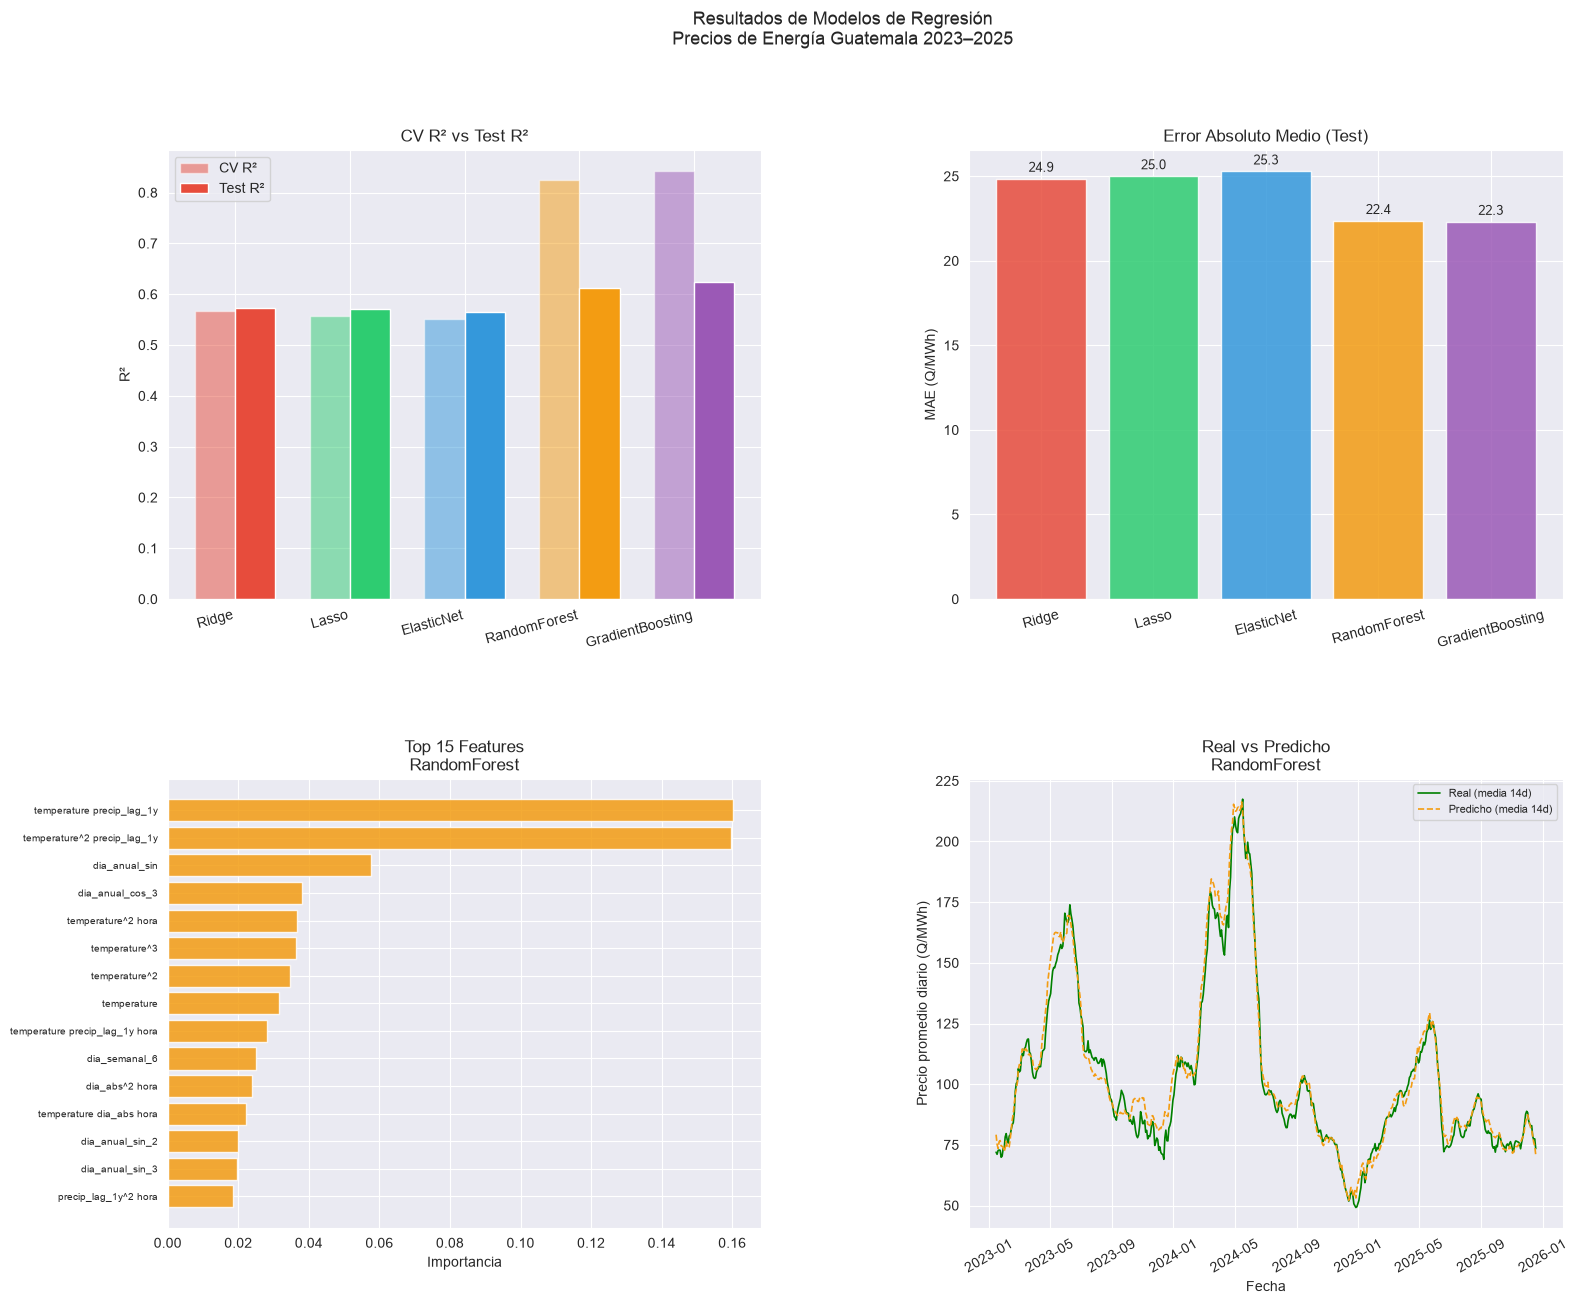

In [16]:
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

model_colors = {
    'Ridge': '#e74c3c', 'Lasso': '#2ecc71', 'ElasticNet': '#3498db',
    'RandomForest': '#f39c12', 'GradientBoosting': '#9b59b6'
}
names = list(results.keys())
cv_r2s = [results[n]['cv_r2'] for n in names]
test_r2s = [results[n]['test_r2'] for n in names]

# Panel 1: CV R² vs Test R²
ax1 = fig.add_subplot(gs[0, 0])
x, w = np.arange(len(names)), 0.35
ax1.bar(x - w / 2, cv_r2s, w, label='CV R²', color=[model_colors[n] for n in names], alpha=0.5)
ax1.bar(x + w / 2, test_r2s, w, label='Test R²', color=[model_colors[n] for n in names], alpha=1.0)
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=15, ha='right')
ax1.set_ylabel('R²')
ax1.set_title('CV R² vs Test R²')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.legend()

# Panel 2: MAE
ax2 = fig.add_subplot(gs[0, 1])
maes = [results[n]['test_mae'] for n in names]
bars = ax2.bar(names, maes, color=[model_colors[n] for n in names], alpha=0.85)
ax2.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax2.set_ylabel('MAE (Q/MWh)')
ax2.set_title('Error Absoluto Medio (Test)')
ax2.tick_params(axis='x', rotation=15)

# Panel 3: Feature importance
ax3 = fig.add_subplot(gs[1, 0])
if hasattr(best_model.named_steps['model'], 'feature_importances_'):
    # Mostrar los featurs más importantes (RandomForest y GradientBoosting)
    imp = pd.DataFrame({
            'feature': FEATURES,
            'importance': best_model.named_steps['model'].feature_importances_
        }).sort_values('importance', ascending=True).tail(15)

    ax3.barh(imp['feature'], imp['importance'], color=model_colors[best_model_name], alpha=0.85)
    ax3.set_xlabel('Importancia')
elif hasattr(best_model.named_steps['model'], 'coef_'):
    # Mostrar los coeficientes más importantes (Lasso, Ridge, y ElasticNet)
    coefs = pd.DataFrame({'feature': FEATURES, 'coef': np.abs(best_model.named_steps['model'].coef_)}
                         ).sort_values('coef', ascending=True).tail(15)
    ax3.barh(coefs['feature'], coefs['coef'], color=model_colors[best_model_name], alpha=0.85)
    ax3.set_xlabel('|Coeficiente|')

ax3.set_title(f'Top 15 Features\n{best_model_name}')
ax3.tick_params(axis='y', labelsize=7)

# Panel 4: Serie de tiempo real vs predicho
ax4 = fig.add_subplot(gs[1, 1])
test_dias  = data.loc[X_test.index, 'dia']
pred_daily = pd.Series(y_pred, index=test_dias.values).groupby(level=0).mean()
real_daily = pd.Series(y_test.values, index=test_dias.values).groupby(level=0).mean()

# Utilizar un rolling window para que la gráfica sea más legible
window = 14
pred_smooth = pred_daily.rolling(window, center=True).mean()
real_smooth = real_daily.rolling(window, center=True).mean()

ax4.plot(real_smooth.index, real_smooth.values, color='green', linewidth=1.2, label=f'Real (media {window}d)')
ax4.plot(pred_smooth.index, pred_smooth.values, color=model_colors[best_model_name],
         linestyle='--', linewidth=1.2, label=f'Predicho (media {window}d)')

ax4.set_xlabel('Fecha')
ax4.set_ylabel('Precio promedio diario (Q/MWh)')
ax4.set_title(f'Real vs Predicho\n{best_model_name}')
ax4.legend(fontsize=8)
ax4.tick_params(axis='x', rotation=30)

plt.suptitle('Resultados de Modelos de Regresión\nPrecios de Energía Guatemala 2023–2025', fontsize=13)
plt.savefig('data/model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Observaciones del Proceso de Entrenamiento

### Lo que descubrimos sobre los datos

Los precios de energía en Guatemala siguen dos ciclos distintos: uno **diario** (más barato de madrugada, más caro al mediodía) y uno **anual** (más barato en diciembre-enero, más caro en mayo-junio). Ambos ciclos son consistentes los tres años.

El año 2024 fue un outlier: los precios fueron significativamente más altos que 2023 y 2025. Esto se explica por El Niño, que redujo las lluvias en la cuenca del Chixoy, vaciando los reservorios hidroeléctricos y forzando generación térmica más cara. Esta variación inter-anual fue el mayor obstáculo para el modelo.

---

### El grid eléctrico de Guatemala y por qué el petróleo no importa

Guatemala genera la mayor parte de su electricidad con agua. Las plantas hidroeléctricas — principalmente sobre el río Chixoy en Alta Verapaz — producen energía a costo marginal casi cero una vez construidas: el agua cae, las turbinas giran, no hay combustible que comprar. En condiciones normales, esto hace que la electricidad guatemalteca sea relativamente barata comparada con países que dependen de gas o petróleo.

El precio spot en el mercado mayorista (AMM) lo determina un sistema de subasta: los generadores ofrecen bloques de energía a distintos precios, y el precio marginal del bloque más caro que se necesita despachar se convierte en el precio de mercado para todos. En época lluviosa, hay tanta agua disponible que los generadores hidráulicos pueden ofrecer precios bajísimos y cubrir toda la demanda. El precio spot cae porque nadie necesita encender una planta de bunker.

Cuando los reservorios se vacían — como ocurrió en 2024 — la hidro no alcanza para cubrir la demanda. El AMM tiene que despachar plantas térmicas: bunker, diesel, carbón. Estas plantas tienen costos operativos altos porque sí consumen combustible. Al entrar al despacho, elevan el precio marginal de mercado, y ese precio sube para todos los compradores.

Por eso **el precio del petróleo WTI no correlacionó con el precio de energía** (R²=0.05 en nuestro análisis). No es que el petróleo no importe — sí importa cuando las térmicas están operando. Pero en condiciones normales las térmicas no operan, y cuando operan, lo hacen principalmente por causa de una sequía, no por un alza en el crudo. La correlación causal va: **lluvia → reservorios → despacho térmico → precio**, no **petróleo → precio**. El petróleo es un factor de tercer orden.

---

### El ciclo ENSO y su efecto retardado en los precios

ENSO (El Niño-Oscilación del Sur) es un fenómeno climático global que alterna entre fases cálidas (El Niño) y frías (La Niña) en el Océano Pacífico. En Guatemala, El Niño suprime las lluvias en las cuencas de la vertiente atlántica y del altiplano. La Niña las intensifica.

El ciclo que observamos en los datos fue el siguiente:

**2022-2023:** La Niña moderada → lluvias abundantes → reservorios llenos al inicio de 2023 → precios bajos y estables durante gran parte del año.

**2023-2024:** Transición a El Niño fuerte → inicio de lluvias retrasado → reservorios que nunca llegaron a llenarse completamente → al entrar la época seca de 2024 (enero-junio), los niveles estaban críticamente bajos → el AMM tuvo que despachar térmicas durante meses → precios disparados, con picos de hasta 350 Q/MWh en abril-mayo de 2024, más del doble del promedio histórico.

**2024-2025:** El Niño se disipó → lluvias de 2024 comenzaron a recuperar reservorios → precios cayeron abruptamente desde julio 2024 en adelante → 2025 mostró los precios más bajos del período analizado.

Lo que esto significa para el modelo: el efecto de El Niño sobre los precios **no es inmediato**. Las lluvias de un año determinan la capacidad hidroeléctrica del año siguiente, no del mismo año. Por eso `precip_lag_1y` — la precipitación acumulada en los 365 días anteriores — resultó ser un predictor más informativo que la precipitación actual. La lluvia de hoy llena el reservorio de mañana y determina el precio de pasado mañana.

Intentamos también usar el Índice Oceánico de El Niño (ONI) directamente desde la NOAA, pero con solo 3 años de datos — un solo ciclo ENSO — la correlación era estadísticamente débil (R²=0.06). Para que el ONI sea un predictor robusto necesitaríamos al menos 10 años de datos históricos del AMM cubriendo múltiples ciclos.

---

### Lo que funcionó y lo que no

**División cronológica → no funcionó.** Entrenar en 2023-2024 y probar en 2025 producía R² negativo. El modelo nunca había visto precios tan bajos como los de 2025 H2, por lo que sobreestimaba sistemáticamente.

**División intercalada (días impares/pares) → funcionó.** Al mezclar los tres años en ambos conjuntos, el modelo aprendió el rango completo de precios. Esto fue el cambio más importante de todo el proceso.

**Features de lag → trampa.** Agregar el precio de hace 24 horas como feature elevaba el R² a 0.85, pero el modelo simplemente aprendía que "el precio de ahora ≈ el precio de hace una hora". Útil para predicción de corto plazo, pero no generaliza a horizontes de semanas o meses. Decidimos no usarlos.

**Features polinomiales → impacto real.** Temperatura y precipitación tienen una relación no-lineal con el precio: no importa tanto si hay 18°C vs 19°C, pero sí importa mucho si la temperatura lleva semanas alta. Los términos polinomiales de grado 5 capturan estas curvas de umbral que una regresión lineal simple no puede aprender.

**Harmónicas adicionales → mejora modesta pero consistente.** El análisis FFT mostró periodicidades a 365, 182 y 90 días. Agregar las harmónicas k=2 y k=3 al encoding sinusoidal captura estos ciclos secundarios sin agregar ruido.

**`precip_lag_1y` → el feature externo más valioso.** La precipitación acumulada del año anterior refleja el estado de los reservorios. Cuando este valor cae — como en 2023-2024 por El Niño — los precios suben. Es más informativo que la temperatura sola y captura la dinámica multi-anual que ningún otro feature disponible podía representar.

---

### Comparación de modelos

Los modelos lineales (Ridge, Lasso, ElasticNet) y los basados en árboles (RandomForest, GradientBoosting) llegaron a resultados similares en Test R² (~0.60-0.65). La diferencia principal:

- Los **modelos lineales** son más estables: su CV R² y Test R² están más cerca entre sí, lo que indica que generalizan bien.
- **GradientBoosting** tuvo el mejor Test R², pero con una brecha mayor entre CV y Test, señal de mayor sobreajuste.
- **Ridge** sorprendentemente competitivo dado su simplicidad, validando que los features polinomiales hicieron el trabajo pesado de capturar no-linealidades.